## Emotion Recognition via EEG (and ECG) Physiological Signals

# Dataset:
DREAMER, a multi-modal database consisting of electroencephalogram (EEG) and
electrocardiogram (ECG) signals recorded during affect elicitation by means of audio-visual stimuli.
Signals from 23 participants were recorded along with the participants’ self-assessment of their
affective state after each stimuli, in terms of valence, arousal, and dominance. All the signals were
captured using portable, wearable, wireless, low-cost and off-the-shelf equipment that has the
potential to allow the use of affective computing methods in everyday applications. The Emotiv EPOC
wireless EEG headset was used for EEG and the Shimmer2 ECG sensor for ECG.

## Dataset Description:
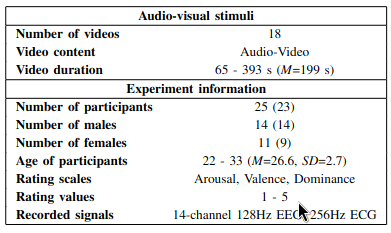
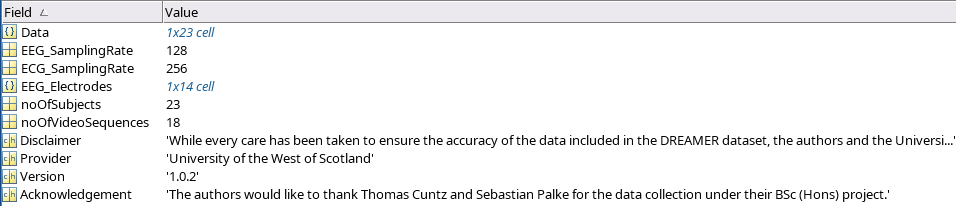

## Electroenchephalogram Signals:
The captured EEG signals were separated into the theta (4 Hz - 8 Hz), alpha (8 Hz - 13 Hz), and beta (13 Hz - 20 Hz) frequency bands. The logarithms of the PSD from each of the aforementioned bands are extracted from the signal of each of the 14 electrodes in order to be used as features


In [1]:
!pip install torcheeg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.4/251.4 kB 6.6 MB/s eta 0:00:0000:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Obtaining dependency information for tqdm>=4.64.0 from https://files.pythonhosted.org/packages/16/e1/3079a9ff9b8e11b846c6ac5c8b5bfb7ff225eee721825310c91b3b50304f/tqdm-4.67.3-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 7.9 MB/s eta 0:00:00
  Obtaining dependency information for numpy>=1.21.5 from https://files.pythonhosted.org/packages/ef/27/d26c85cbcd86b26e4f125b0668e7a7c0542d19dd7d23ee12e87b550e95b5/numpy-2.4.3-cp311-cp311-macosx_14_0_arm64.whl.metadata
  Obtaining dependency information for pandas>=1.3.5 from https://files.pythonhosted.org/packages/c1/27/90683c7122febeefe84a56f2cde86a9f05f68d53885cebcc473298dfc33e/pandas-3.0.1-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 

First off, we’ll use the DREAMER dataset provided by TorchEEG. Each EEG sample in this dataset spans 1 second and contains 128 data points. For each trial, the baseline signal lasts 61 seconds. During offline preprocessing, we perform several steps: - Divide each electrode’s EEG signal into 4 frequency sub-bands - Compute the differential entropy of each sub-band as a feature - Eliminate the baseline from the signal - Map the preprocessed signals onto a 2D grid For online processing, we convert the EEG signals into PyTorch Tensors to make them compatible with neural network inputs. Let’s see how to accomplish these steps in code.

In [2]:
from torcheeg.datasets import DREAMERDataset
from torcheeg import transforms

dataset = DREAMERDataset(io_path='./examples_dreamer_tsception/dreamer',
                         mat_path='/kaggle/input/dreamer/DREAMER.mat',
                         offline_transform=transforms.Compose([
                             transforms.BaselineRemoval(),
                             transforms.MeanStdNormalize(),
                             transforms.To2d()
                         ]),
                         online_transform=transforms.ToTensor(),
                         label_transform=transforms.Compose([
                             transforms.Select('valence'),
                             transforms.Binary(3.0)
                         ]),
                         chunk_size=128,
                         baseline_chunk_size=128,
                         num_baseline=61,
                         num_worker=4)

[2024-08-08 05:41:03] INFO (torcheeg/MainThread) 🔍 | Processing EEG data. Processed EEG data has been cached to ./examples_dreamer_tsception/dreamer.
[2024-08-08 05:41:03] INFO (torcheeg/MainThread) ⏳ | Monitoring the detailed processing of a record for debugging. The processing of other records will only be reported in percentage to keep it clean.
[PROCESS]:  17%|█▋        | 4/23 [00:00<00:00, 36.14it/s]
[RECORD 0]: 0it [00:00, ?it/s]
[RECORD 0]: 1it [00:11, 11.86s/it]
[RECORD 0]: 16it [00:11,  1.87it/s]
[RECORD 0]: 31it [00:12,  4.34it/s]
[RECORD 0]: 46it [00:12,  7.72it/s]
[RECORD 0]: 61it [00:12, 12.28it/s]
[RECORD 0]: 76it [00:12, 18.31it/s]
[RECORD 0]: 91it [00:12, 26.06it/s]
[RECORD 0]: 106it [00:12, 35.54it/s]
[RECORD 0]: 121it [00:12, 46.92it/s]
[RECORD 0]: 139it [00:12, 63.03it/s]
[RECORD 0]: 156it [00:12, 78.79it/s]
[RECORD 0]: 172it [00:13, 91.62it/s]
[RECORD 0]: 188it [00:13, 102.66it/s]
[RECORD 0]: 204it [00:13, 114.93it/s]
[RECORD 0]: 221it [00:13, 126.48it/s]
[PROCESS]:

In [3]:
from torcheeg.model_selection import KFoldGroupbyTrial

k_fold = KFoldGroupbyTrial(n_splits=5,
                           split_path=f'./examples_dreamer_tsception/split')

In [4]:
from torch.utils.data import DataLoader
from torcheeg.models import TSCeption

from torcheeg.trainers import ClassifierTrainer

import pytorch_lightning as pl

for i, (train_dataset, val_dataset) in enumerate(k_fold.split(dataset)):
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model = TSCeption(num_electrodes=14,
                      num_classes=2,
                      num_T=15,
                      num_S=15,
                      in_channels=1,
                      hid_channels=32,
                      sampling_rate=128,
                      dropout=0.5)

    trainer = ClassifierTrainer(model=model,
                                num_classes=2,
                                lr=1e-4,
                                weight_decay=1e-4,
                                accelerator="gpu")
    trainer.fit(train_loader,
                val_loader,
                max_epochs=50,
                default_root_dir=f'./examples_dreamer_tsception/model/{i}',
                callbacks=[pl.callbacks.ModelCheckpoint(save_last=True)],
                enable_progress_bar=True,
                enable_model_summary=True,
                limit_val_batches=0.0)
    score = trainer.test(val_loader,
                         enable_progress_bar=True,
                         enable_model_summary=True)[0]
    print(f'Fold {i} test accuracy: {score["test_accuracy"]:.4f}')

[2024-08-08 05:45:12] INFO (torcheeg/MainThread) 📊 | Create the split of train and test set.
[2024-08-08 05:45:12] INFO (torcheeg/MainThread) 😊 | Please set split_path to ./examples_dreamer_tsception/split for the next run, if you want to use the same setting for the experiment.
2024-08-08 05:45:18.937668: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-08 05:45:18.937764: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-08 05:45:19.071205: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/opt/conda/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_con

Training: |          | 0/? [00:00<?, ?it/s]

[2024-08-08 05:45:51] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.665 train_accuracy: 0.595 

[2024-08-08 05:46:15] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.617 train_accuracy: 0.659 

[2024-08-08 05:46:38] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.580 train_accuracy: 0.692 

[2024-08-08 05:47:02] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.556 train_accuracy: 0.711 

[2024-08-08 05:47:25] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.537 train_accuracy: 0.725 

[2024-08-08 05:47:48] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.523 train_accuracy: 0.736 

[2024-08-08 05:48:12] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.510 train_accuracy: 0.745 

[2024-08-08 05:48:35] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.500 train_accuracy: 0.751 

[2024-08-08 05:48:58] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.491 train_accuracy: 0.756 

[2024-08-08 05:49:21] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.482 train_accuracy: 0.762 



Testing: |          | 0/? [00:00<?, ?it/s]

[2024-08-08 06:05:06] INFO (torcheeg/MainThread) 
[Test] test_loss: 0.517 test_accuracy: 0.752 



...

[2024-08-08 07:04:58] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.653 train_accuracy: 0.617 

[2024-08-08 07:05:22] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.615 train_accuracy: 0.663 

[2024-08-08 07:05:46] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.586 train_accuracy: 0.689 

[2024-08-08 07:06:09] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.564 train_accuracy: 0.706 

[2024-08-08 07:06:32] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.547 train_accuracy: 0.722 

[2024-08-08 07:06:56] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.534 train_accuracy: 0.730 

[2024-08-08 07:07:19] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.521 train_accuracy: 0.739 

[2024-08-08 07:07:43] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.510 train_accuracy: 0.746 

[2024-08-08 07:08:06] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.503 train_accuracy: 0.751 

[2024-08-08 07:08:30] INFO (torcheeg/MainThread) 
[Train] train_loss: 0.494 train_accuracy: 0.756 



Testing: |          | 0/? [00:00<?, ?it/s]

[2024-08-08 07:24:07] INFO (torcheeg/MainThread) 
[Test] test_loss: 0.481 test_accuracy: 0.772 



┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test_accuracy       │    0.7716803550720215     │
│         test_loss         │    0.4811123013496399     │
└───────────────────────────┴───────────────────────────┘

Fold 4 test accuracy: 0.7717
